# Final Calibration TrussLab:
___

In [1]:
import TrussLab.bridge_manager as br
import TrussLab.beam_manager as be

import matplotlib.pyplot as plt
import numpy as np

R_ref = 99.8 # Ohm

All required modules were succesfully loaded.


Default Beam Library Impedance:

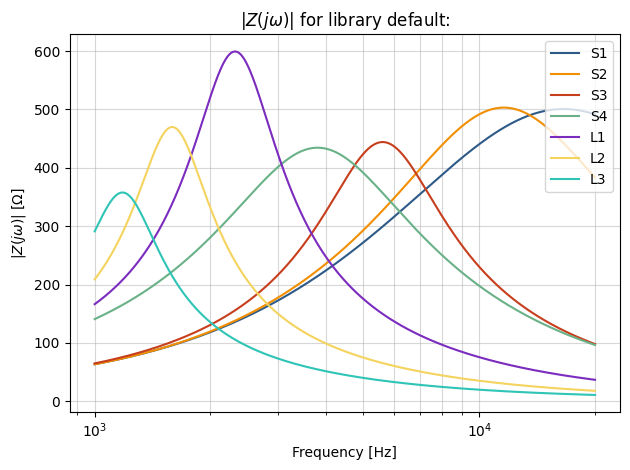

In [2]:
library_name = 'default'
library = be.open_beam_library(library_name + '.json')

fig, ax = plt.subplots()
colors = ['#2E5A88', '#F18F01', '#C73E1D', '#6AB187', '#7B2CBF', '#F4D35E', '#2EC4B6']
f_logrange = (3, np.log10(2e4)) # max frequency sweep between 1 and 20 kHz
f_start, f_stop = f_logrange
f_arr = np.logspace(f_start, f_stop, 2000)

for beam, color in zip(list(library.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

## Individual Truss measurements:
___

c:\Users\jules\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_differentiable_functions.py:728: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


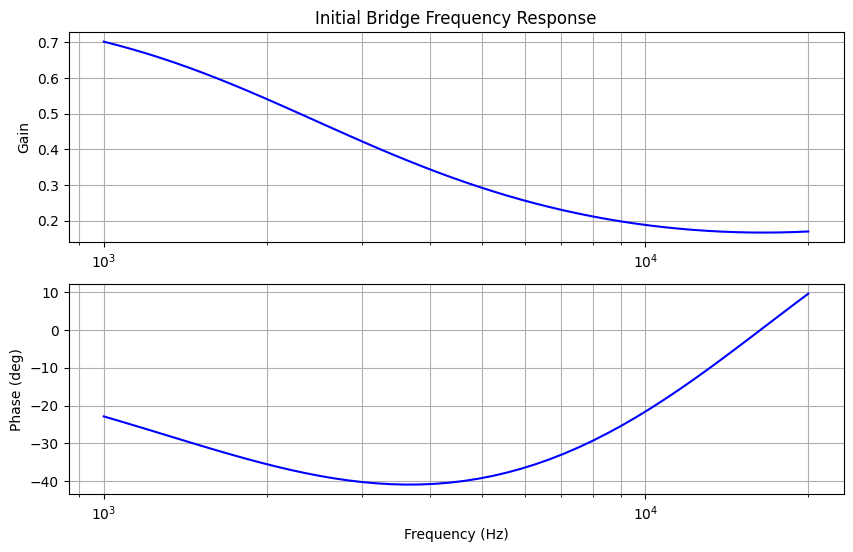

In [3]:
library = be.open_beam_library('default.json')
truss = br.Bridge()

selection = ['S1']        # Beam selection
topology = [(0, 1)]   # Beam topology
rigid = 0                             # rigid or single DOF?

lib = be.sublibrary(selection, library)

truss.construct(lib, topology, rigid=rigid)

f_arr_plot = np.logspace(3, np.log10(2e4))
U_initial = truss.initial_response(f_arr_plot, R_ref, plot=True)

In [4]:
# Sweep settings:
# ----------------------------------------------------------------------------------------
freqsteps = 50

resonance_sweep = True
geo_constraint = False

myDAQlog = None # In case we want to use previous measurements, plug 'result.txt' in here!
save_filename = 'S1_NORS_f200' # Saved file name

error_plot = True
R_var = [0]
R_def = [beam.R_0 for beam in list(truss.library.values())]

response_comparison_plot = True
include_mes = True
# ----------------------------------------------------------------------------------------

R_mes, x_mes = truss.sweep(R_ref, f_logrange=(3, np.log10(2e4)), freqsteps=freqsteps, 
                           myDAQ=True, myDAQlog=None, save_filename=save_filename,
                           resonance_sweep=resonance_sweep, geo_constraint=geo_constraint,
                           position_plot=True, error_plot=error_plot, R_var=R_var, R_def=R_def, 
                           response_comparison_plot=response_comparison_plot, include_mes=include_mes)

print(f'The found R-values were {R_mes}, while the (undeformed) database values were {R_def}.')
print(f'The estimated nodal position vector was {x_mes}.')

Targeting 0 base features at (Hz): []
  R_S1: Unique feature allocated at 17600.1 Hz
myDAQsweep started...


c:\Users\jules\OneDrive - Delft University of Technology\Y3 WB TU Delft\BEP 2026\Python\repo\TrussLab\bridge_manager.py:1014: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel(f'$R_{{{list(self.library.keys())[idx]}}}$ ($\Omega$)')
c:\Users\jules\OneDrive - Delft University of Technology\Y3 WB TU Delft\BEP 2026\Python\repo\TrussLab\bridge_manager.py:1015: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel(f'$R_{{{list(self.library.keys())[idy]}}}$ ($\Omega$)')
c:\Users\jules\OneDrive - Delft University of Technology\Y3 WB TU Delft\BEP 2026\Python\repo\TrussLab\myDAQ_manager.py:21: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filename_log, skiprows=3, sep='\s+', decimal=',',


com_error: (-2147221005, 'Ongeldige klassereeks', None, None)